## imports 

In [1]:
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

 ## Read Data

In [4]:
file_name = input("Please Enter your file as path: ")
file_name = file_name.replace('\\', '/')  # Replace backslashes with forward slashes
 
try:
    # Load the CSV file
    data = pd.read_csv(file_name)
except FileNotFoundError:
    print(f"File not found: {file_name}. Ensure the file is in the same directory as your script.")
except Exception as e:
    print(f"An error occurred: {e}")

Please Enter your file as path:  C:\Users\rahma\Desktop\life expectancy.csv


## Exploration 


In [6]:
print(data.head())   #returns the first 5 rows.

           Country Name Country Code                      Region  \
0           Afghanistan          AFG                  South Asia   
1                Angola          AGO          Sub-Saharan Africa   
2               Albania          ALB       Europe & Central Asia   
3               Andorra          AND       Europe & Central Asia   
4  United Arab Emirates          ARE  Middle East & North Africa   

           IncomeGroup  Year  Life Expectancy World Bank  \
0           Low income  2001                      56.308   
1  Lower middle income  2001                      47.059   
2  Upper middle income  2001                      74.288   
3          High income  2001                         NaN   
4          High income  2001                      74.544   

   Prevelance of Undernourishment      CO2  Health Expenditure %  \
0                            47.8    730.0                   NaN   
1                            67.5  15960.0              4.483516   
2                         

In [8]:
print(data.tail())    #returns the last 5 rows.

      Country Name Country Code               Region          IncomeGroup  \
3301       Vanuatu          VUT  East Asia & Pacific  Lower middle income   
3302         Samoa          WSM  East Asia & Pacific  Lower middle income   
3303  South Africa          ZAF   Sub-Saharan Africa  Upper middle income   
3304        Zambia          ZMB   Sub-Saharan Africa           Low income   
3305      Zimbabwe          ZWE   Sub-Saharan Africa  Lower middle income   

      Year  Life Expectancy World Bank  Prevelance of Undernourishment  \
3301  2019                      70.474                            12.4   
3302  2019                      73.321                             4.4   
3303  2019                      64.131                             6.3   
3304  2019                      63.886                             NaN   
3305  2019                      61.490                             NaN   

                CO2  Health Expenditure %  Education Expenditure %  \
3301     209.999993   

In [10]:
df = pd.DataFrame(data)
unique_countries = df['Country Name'].nunique() # to get the number of countries used in the dataset
print(unique_countries)

174


In [12]:
print("Dimensions: ", data.shape)     #returns the number of rows and columns in dataset.

Dimensions:  (3306, 16)


In [14]:
print(data.info())                    #returns a summary for the dataset.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3306 entries, 0 to 3305
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Country Name                    3306 non-null   object 
 1   Country Code                    3306 non-null   object 
 2   Region                          3306 non-null   object 
 3   IncomeGroup                     3306 non-null   object 
 4   Year                            3306 non-null   int64  
 5   Life Expectancy World Bank      3118 non-null   float64
 6   Prevelance of Undernourishment  2622 non-null   float64
 7   CO2                             3154 non-null   float64
 8   Health Expenditure %            3126 non-null   float64
 9   Education Expenditure %         2216 non-null   float64
 10  Unemployment                    3002 non-null   float64
 11  Corruption                      975 non-null    float64
 12  Sanitation                      20

In [16]:
missing_values = data.isnull().sum()  
print("Missing values:\n",missing_values)   #returns the # of null values per column. 

Missing values:
 Country Name                         0
Country Code                         0
Region                               0
IncomeGroup                          0
Year                                 0
Life Expectancy World Bank         188
Prevelance of Undernourishment     684
CO2                                152
Health Expenditure %               180
Education Expenditure %           1090
Unemployment                       304
Corruption                        2331
Sanitation                        1247
Injuries                             0
Communicable                         0
NonCommunicable                      0
dtype: int64


In [18]:
duplicated_values = data.duplicated().sum() 
print("Duplicate values: " ,duplicated_values)       # returns the # of duplicate rows.

Duplicate values:  0


In [20]:
print("Statistical Summary: ", data.describe())          #returns the count, mean, std, quartiles, min and max.

Statistical Summary:                Year  Life Expectancy World Bank  \
count  3306.000000                 3118.000000   
mean   2010.000000                   69.748362   
std       5.478054                    9.408154   
min    2001.000000                   40.369000   
25%    2005.000000                   63.642000   
50%    2010.000000                   72.168500   
75%    2015.000000                   76.809000   
max    2019.000000                   84.356341   

       Prevelance of Undernourishment           CO2  Health Expenditure %  \
count                     2622.000000  3.154000e+03           3126.000000   
mean                        10.663654  1.574924e+05              6.364059   
std                         11.285897  7.726415e+05              2.842844   
min                          2.500000  1.000000e+01              1.263576   
25%                          2.500000  2.002500e+03              4.205443   
50%                          6.200000  1.020500e+04              

In [22]:
mode = data.mode()
print("Mode: ", mode)                                 #returns the mode for each column.

Mode:          Country Name Country Code                 Region  IncomeGroup    Year  \
0        Afghanistan          AFG  Europe & Central Asia  High income  2001.0   
1            Albania          AGO                    NaN          NaN  2002.0   
2            Algeria          ALB                    NaN          NaN  2003.0   
3     American Samoa          AND                    NaN          NaN  2004.0   
4            Andorra          ARE                    NaN          NaN  2005.0   
...              ...          ...                    ...          ...     ...   
3301             NaN          NaN                    NaN          NaN     NaN   
3302             NaN          NaN                    NaN          NaN     NaN   
3303             NaN          NaN                    NaN          NaN     NaN   
3304             NaN          NaN                    NaN          NaN     NaN   
3305             NaN          NaN                    NaN          NaN     NaN   

      Life Expectanc

In [24]:
unique_values = data.nunique()
print("Unique values in columns:\n", unique_values)    #returns # unique values per column.

Unique values in columns:
 Country Name                       174
Country Code                       174
Region                               7
IncomeGroup                          4
Year                                19
Life Expectancy World Bank        2966
Prevelance of Undernourishment     399
CO2                               2259
Health Expenditure %              3126
Education Expenditure %           2192
Unemployment                      2151
Corruption                           8
Sanitation                        1941
Injuries                          3306
Communicable                      3306
NonCommunicable                   3306
dtype: int64


In [26]:
print(data.dtypes)       #returns the data type for each column.

Country Name                       object
Country Code                       object
Region                             object
IncomeGroup                        object
Year                                int64
Life Expectancy World Bank        float64
Prevelance of Undernourishment    float64
CO2                               float64
Health Expenditure %              float64
Education Expenditure %           float64
Unemployment                      float64
Corruption                        float64
Sanitation                        float64
Injuries                          float64
Communicable                      float64
NonCommunicable                   float64
dtype: object


## Cleaning

In [29]:
data_cleaned = data.drop(columns=['Corruption','Sanitation','Education Expenditure %'])  #delete columns that have more than 1000 null values

In [31]:
missing_values = data_cleaned.isnull().sum()
print("Missing values:\n" ,missing_values)

Missing values:
 Country Name                        0
Country Code                        0
Region                              0
IncomeGroup                         0
Year                                0
Life Expectancy World Bank        188
Prevelance of Undernourishment    684
CO2                               152
Health Expenditure %              180
Unemployment                      304
Injuries                            0
Communicable                        0
NonCommunicable                     0
dtype: int64


In [33]:
print("Dimensions: ", data_cleaned.shape)     #returns the number of rows and columns in dataset.

Dimensions:  (3306, 13)


In [35]:
data_cleaned = data_cleaned.dropna()    #delete rows that have null values
missing_values = data_cleaned.isnull().sum()  #show that it has no null values
print("Missing values:\n" ,missing_values)

Missing values:
 Country Name                      0
Country Code                      0
Region                            0
IncomeGroup                       0
Year                              0
Life Expectancy World Bank        0
Prevelance of Undernourishment    0
CO2                               0
Health Expenditure %              0
Unemployment                      0
Injuries                          0
Communicable                      0
NonCommunicable                   0
dtype: int64


In [37]:
print("Dimensions: ", data_cleaned.shape)  #returns the number of rows and columns in cleaned dataset.

Dimensions:  (2551, 13)


In [39]:
data_cleaned['Life Expectancy World Bank'] = data_cleaned['Life Expectancy World Bank'].astype(int)  
print(data_cleaned[['Life Expectancy World Bank']].head())

   Life Expectancy World Bank
1                          47
2                          74
4                          74
5                          73
6                          71


In [41]:
# Function to detect outliers for all numerical columns
def detect_outliers_all_columns(data):
    outlier_info = {}
    numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns
    for column in numerical_cols:
        Q1 = data[column].quantile(0.25)
        Q3 = data[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
        outlier_info[column] = {
            "count": outliers.shape[0],
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "outliers": outliers
        }
    return outlier_info

# Detect outliers in all numerical columns
outlier_info = detect_outliers_all_columns(data_cleaned)

# Print outlier information for each column
for column, info in outlier_info.items():
    print(f"\nColumn: {column}")
    print(f"Number of Outliers: {info['count']}")



Column: Year
Number of Outliers: 0

Column: Prevelance of Undernourishment
Number of Outliers: 133

Column: CO2
Number of Outliers: 391

Column: Health Expenditure %
Number of Outliers: 21

Column: Unemployment
Number of Outliers: 181

Column: Injuries
Number of Outliers: 330

Column: Communicable
Number of Outliers: 403

Column: NonCommunicable
Number of Outliers: 335


## visualization

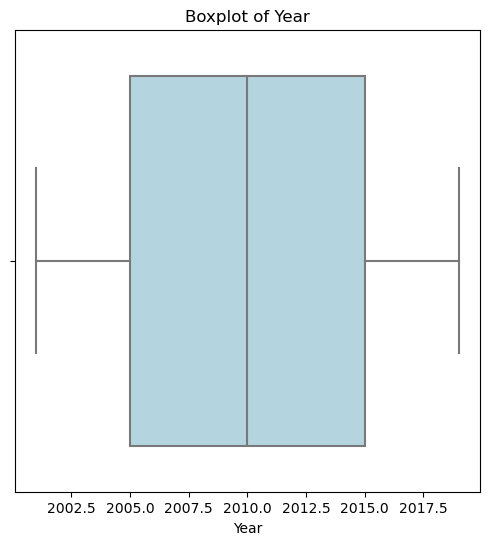

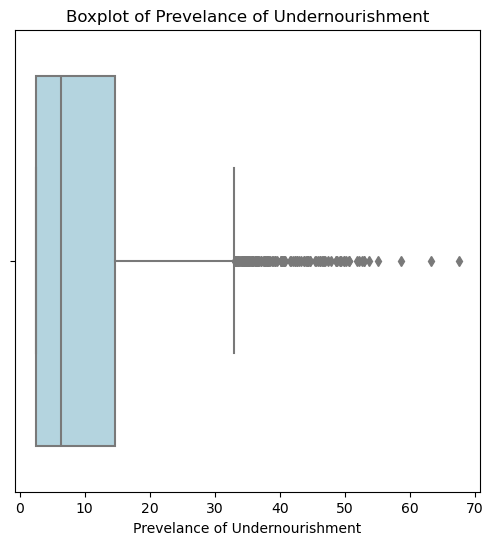

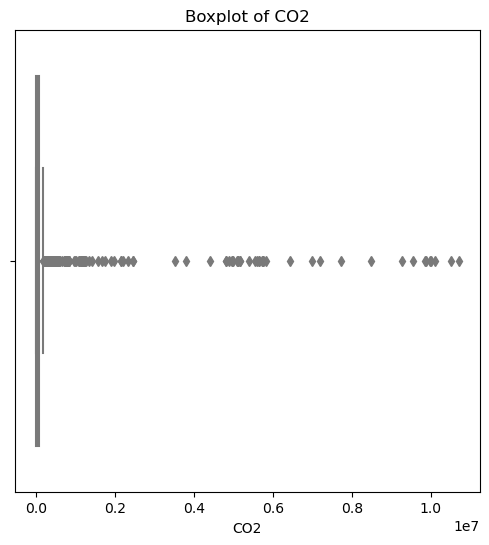

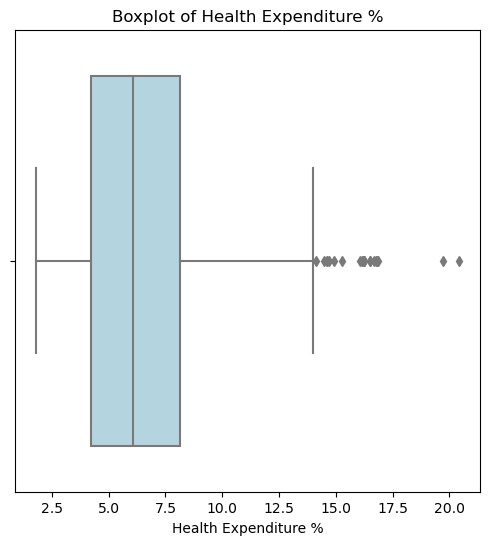

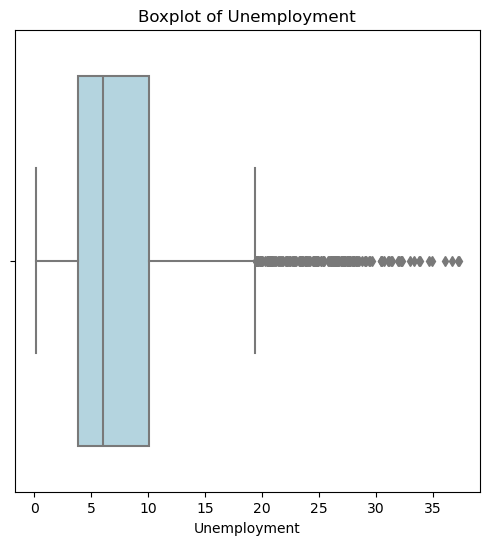

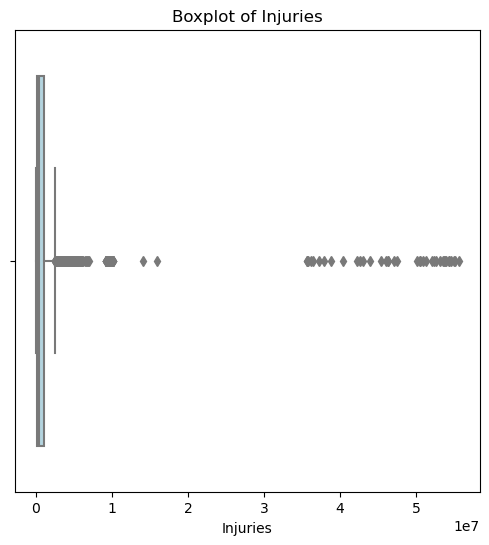

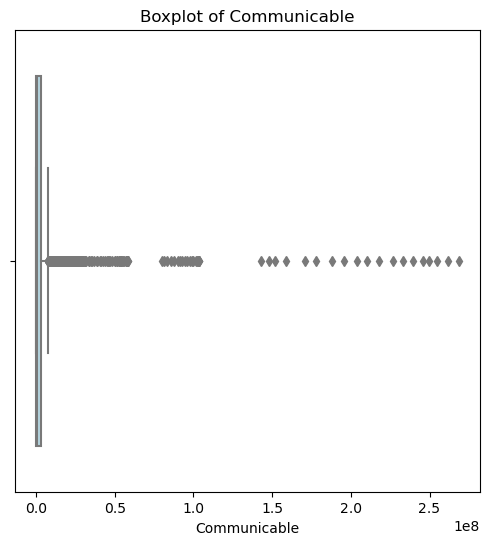

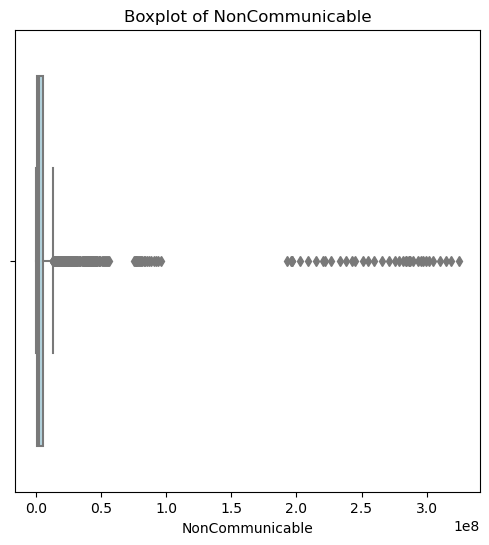

In [44]:
numerical_cols = data_cleaned.select_dtypes(include=['int64', 'float64']).columns

for column in numerical_cols:
    plt.figure(figsize=(6, 6))
    sns.boxplot(data=data_cleaned, x=column, color="lightblue")
    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)
    plt.show()

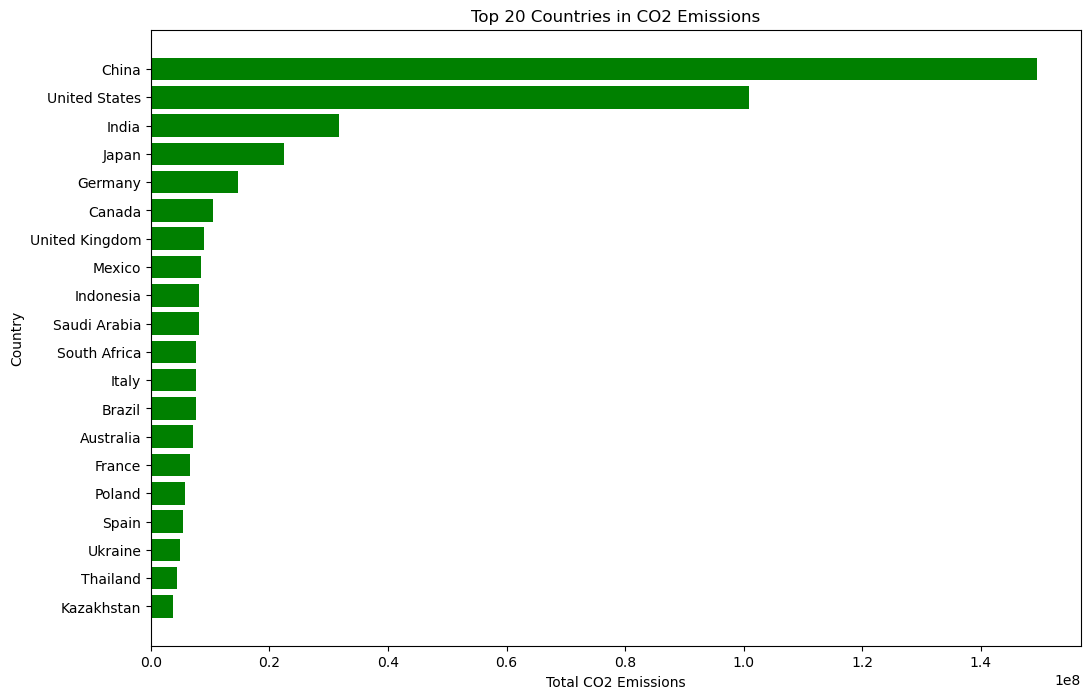

In [45]:
# Group by country and sum the CO2 emissions
co2_emissions = data_cleaned.groupby('Country Name')['CO2'].sum().reset_index()

# Sort the countries by CO2 emissions in descending order and select the top 20
top_20_co2 = co2_emissions.sort_values(by='CO2', ascending=False).head(20)

# Plot the top 20 countries in CO2 emissions
plt.figure(figsize=(12, 8))
plt.barh(top_20_co2['Country Name'], top_20_co2['CO2'], color='green')
plt.xlabel('Total CO2 Emissions')
plt.ylabel('Country')
plt.title('Top 20 Countries in CO2 Emissions')
plt.gca().invert_yaxis()
plt.show()

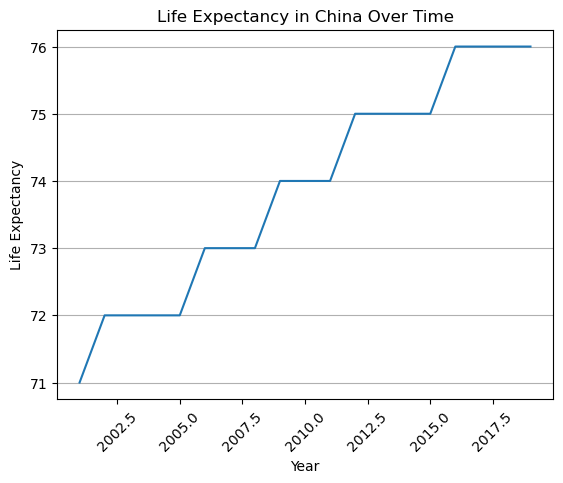

In [46]:
# Plot the life expectancy trend in China over time
d_country = data_cleaned[data_cleaned['Country Name'] == 'China']
data_cleaned['Year'] = data_cleaned['Year'].astype(str)# Prevents conversion to float
plt.plot(d_country['Year'], d_country['Life Expectancy World Bank'])

plt.xticks(rotation=45) # this make rotation for x-axis values and 
plt.grid (axis='y')
plt.xlabel('Year')
plt.ylabel('Life Expectancy')
plt.title('Life Expectancy in China Over Time')
plt.show()

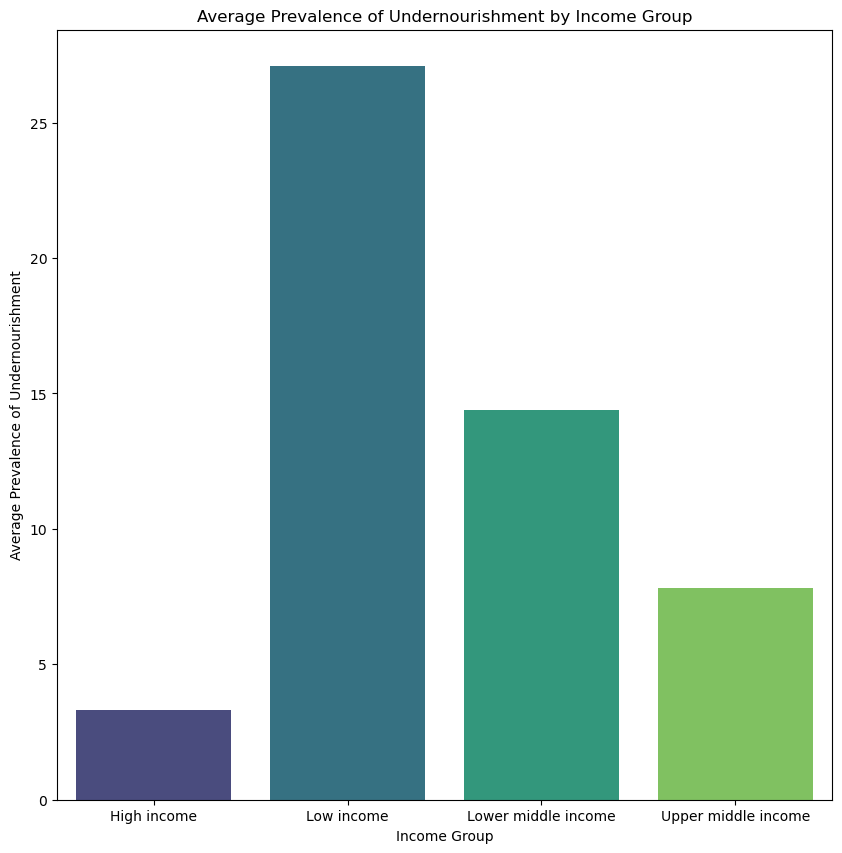

In [47]:
# Group by income group and calculate the mean prevalence of undernourishment
avg_undernourishment = data_cleaned.groupby('IncomeGroup')['Prevelance of Undernourishment'].mean().reset_index()
plt.figure(figsize=(10, 10))
sns.barplot(data=avg_undernourishment, x='IncomeGroup', y='Prevelance of Undernourishment', palette='viridis')
plt.xlabel('Income Group')
plt.ylabel('Average Prevalence of Undernourishment')
plt.title('Average Prevalence of Undernourishment by Income Group')

plt.show()

<Figure size 1200x800 with 0 Axes>

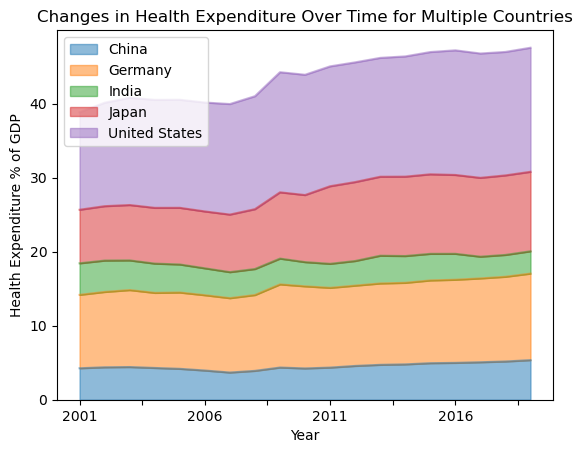

In [54]:
# Filter data for 5 countries 
# selected countries between low and high income
countries = ['India', 'United States', 'China','Japan', 'Germany'] # selected countries between low income and high also
df_countries = data_cleaned[data_cleaned['Country Name'].isin(countries)]

# Pivot the data to have years as index and countries as columns
df_pivot = df_countries.pivot(index='Year', columns='Country Name', values='Health Expenditure %')

# Plot an area chart showing changes in health expenditure over time for multiple countries
plt.figure(figsize=(12, 8))
df_pivot.plot(kind='area', alpha=0.5)
plt.xlabel('Year')
plt.ylabel('Health Expenditure % of GDP')
plt.title('Changes in Health Expenditure Over Time for Multiple Countries')
plt.legend(loc='upper left')
plt.show()

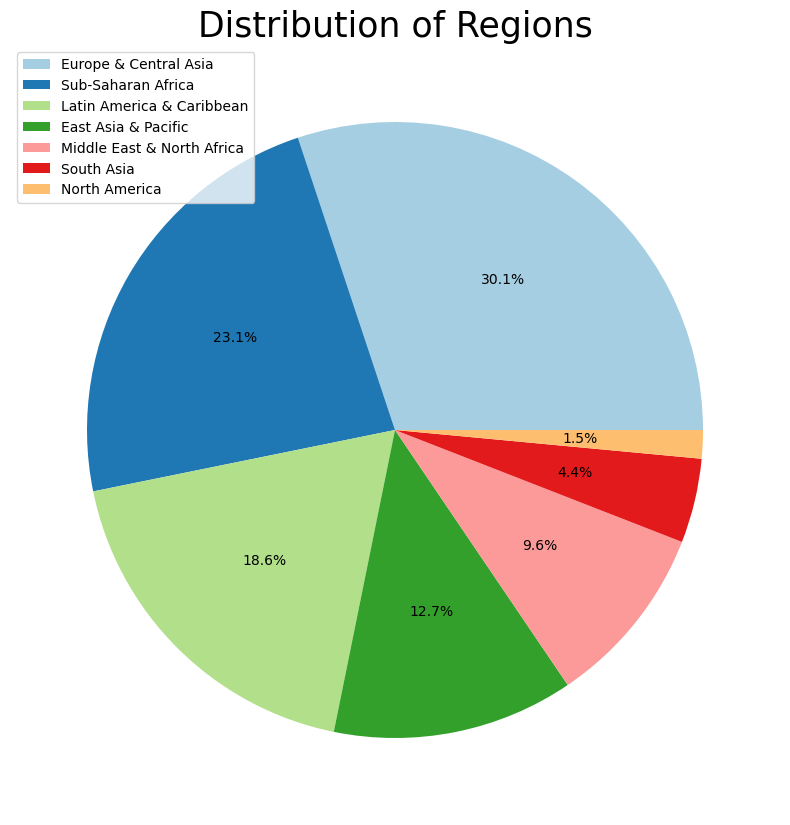

In [56]:
# Pie Chart of Regional Distribution
region_counts = data_cleaned['Region'].value_counts()

plt.figure(figsize=(12, 10))
plt.pie(region_counts,
    autopct='%1.1f%%',               # Display percentage values on slices
    colors=plt.cm.Paired(range(len(region_counts)))
)
plt.legend(region_counts.index, loc="upper left")
plt.title('Distribution of Regions',fontsize=25)
plt.show()


Further more Analyses:


In [59]:
# to answer the question what is the least region in life expectancy 
# may help some organization know the cause based on this relationship 
data_cleaned.groupby('Region').agg({'Life Expectancy World Bank':['mean','max','min']})

Life Expectancy World Bank        
                                                 mean max min
Region                                                       
East Asia & Pacific                         71.142415  84  59
Europe & Central Asia                       76.216146  83  63
Latin America & Caribbean                   72.842105  80  57
Middle East & North Africa                  73.897959  82  57
North America                               78.973684  82  76
South Asia                                  67.061947  76  56
Sub-Saharan Africa                          57.032258  74  40

In [61]:
# find the relationship between region and unemployment 
data_cleaned.groupby('Region').agg({'Unemployment':['mean','max','min','count']})

Unemployment                       
                                   mean        max   min count
Region                                                        
East Asia & Pacific            3.421969   8.750000  0.14   323
Europe & Central Asia          9.777961  37.250000  1.81   768
Latin America & Caribbean      7.083006  19.590000  1.58   475
Middle East & North Africa     9.663629  28.216999  0.80   245
North America                  6.459737   9.630000  3.67    38
South Asia                     4.998973  11.352000  0.40   113
Sub-Saharan Africa             8.806784  34.634998  0.60   589

C:\Users\rahma\AppData\Local\Temp\ipykernel_20876\2680501136.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data= data_cleaned, x="Year", y="Unemployment", hue="Region", marker="o", ci= None)
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. P

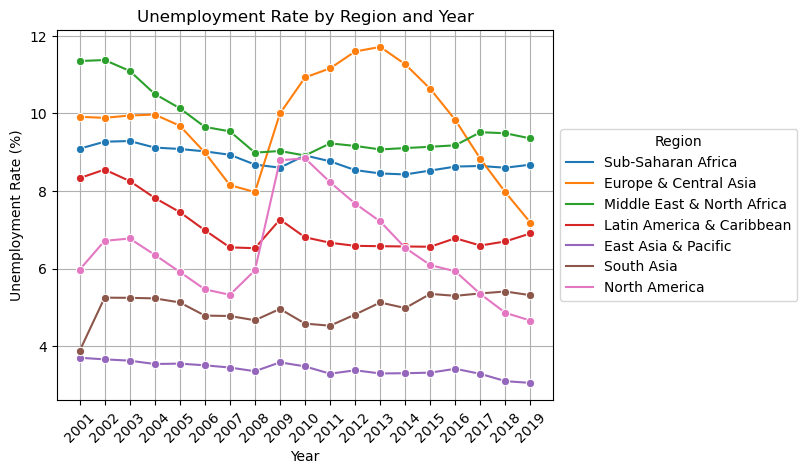

In [63]:

sns.lineplot(data= data_cleaned, x="Year", y="Unemployment", hue="Region", marker="o", ci= None)
plt.legend(title="Region", loc="center left", bbox_to_anchor=(1, 0.5)) # to avoid ovelapping the legend over the graph

plt.xticks(rotation=45) # this make rotation for x-axis values and make it readable 
plt.title("Unemployment Rate by Region and Year")
plt.xlabel("Year")
plt.ylabel("Unemployment Rate (%)")
plt.grid(True)
plt.show()